# Exercise 12 - 2025: A training with a small chemical reaction

## In this exercise we want to train a potential and test some active learning on the simple model. We thank Dr. Umberto Raucci for the collaboration. The reaction is similar to the one studied by Umberto Raucci in this [paper](https://pubs.acs.org/doi/10.1021/acs.jpclett.5c00688).

In [1]:
import numpy as np
import scipy
from scipy.special import sph_harm
from glob import glob
from ase.io import read,write
from ase import neighborlist
import matplotlib.pyplot as plt

import numpy as np
from ase.visualize import view
import matplotlib.pyplot as plt
import nglview as nv

import ase
import ase.io
import ase.lattice.cubic
import ase.md
from ase.md.nvtberendsen import NVTBerendsen
from ase.units import fs, kB
from ase.calculators.lammpsrun import LAMMPS


def view_structure(system):
    t = nv.ASEStructure(system) 
    w = nv.NGLWidget(t, gui=True)
    w.add_spacefill()
    return w


def view_trajectory(trajectory):
    t2 = nv.ASETrajectory(trajectory)
    w2 = nv.NGLWidget(t2, gui=True)
    w2.add_representation('label',label_type='atomindex',color='black')
    w2.add_representation('licorice')
    w2.add_representation('spacefill',selection=[5],color="red",radius=0.7)
    w2.add_representation('ball_and_stick')
    return w2

# First part: harvesting the "ab initio configurations" and training the potential.

---

# Assigment 1

Go to the subdirectory <code>s0/00_iteration/newmodel</code> and train the potential with the command <code>bash train_1.sh</code>. Add an "&" if you want to see the files during the run. 

**1.)** Plot the error in the training along the training and show the decay. Comment on it. Even if the training is not over, stop the training, "touch" the file <code>tag_0_finished</code> and rerun **train_1.sh** to create the frozen model and the compressed one at this point. You can always restart later.

In [2]:
!cd s0/00_iteration/newmodel && tail lcurve.out

 399100      4.40e-02      5.54e-04      4.31e-02    3.9e-08
 399200      5.09e-02      1.08e-03      4.97e-02    3.9e-08
 399300      4.77e-02      8.22e-04      4.66e-02    3.9e-08
 399400      3.87e-02      6.66e-04      3.79e-02    3.9e-08
 399500      5.22e-02      8.07e-04      5.11e-02    3.9e-08
 399600      4.56e-02      8.21e-04      4.46e-02    3.9e-08
 399700      4.49e-02      4.75e-04      4.40e-02    3.9e-08
 399800      3.48e-02      5.15e-04      3.41e-02    3.9e-08
 399900      4.37e-02      9.38e-04      4.27e-02    3.9e-08
 400000      3.48e-02      4.59e-04      3.41e-02    3.5e-08


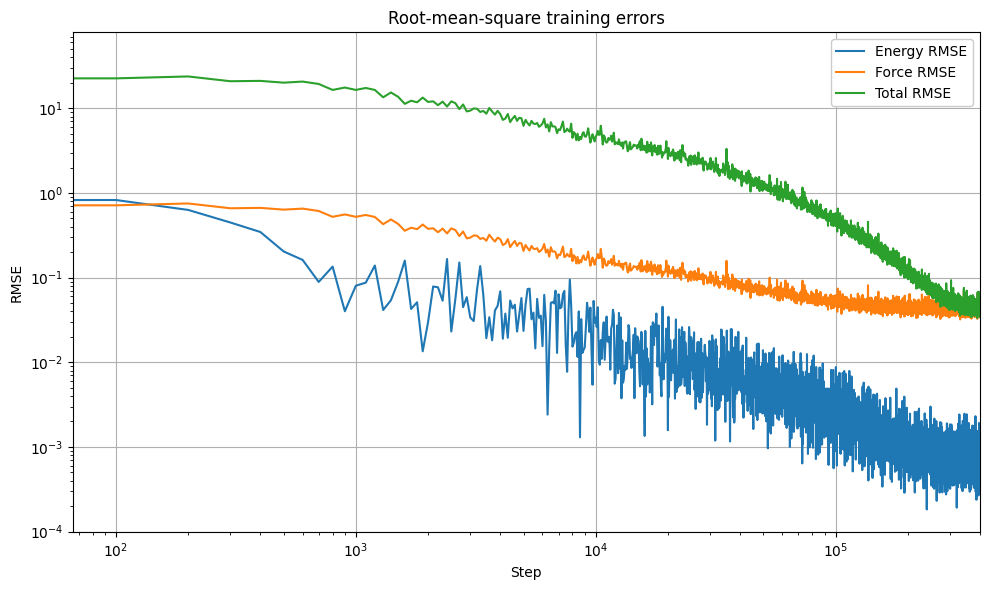

In [3]:
import pandas as pd

column_names = ['step', 'rmse_trn', 'rmse_e_trn', 'rmse_f_trn', 'lr']

df = pd.read_csv('s0/00_iteration/newmodel/lcurve.out', sep='\s+', comment='#', names=column_names)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(df['step'], df['rmse_e_trn'], label='Energy RMSE')
plt.plot(df['step'], df['rmse_f_trn'], label='Force RMSE')
plt.plot(df['step'], df['rmse_trn'], label='Total RMSE')

plt.xlabel('Step')
plt.ylabel('RMSE')
plt.xscale('log')
plt.yscale('log')
plt.xlim((None, 4e5))
plt.title('Root-mean-square training errors')
legend = plt.legend()
legend.get_frame().set_alpha(None)
plt.grid(True)
plt.tight_layout()
plt.show()

**1.)**
> Plot the error in the training along the training and show the decay. Comment on it. Even if the training is not over, stop the training, "touch" the file <code>tag_0_finished</code> and rerun **train_1.sh** to create the frozen model and the compressed one at this point. You can always restart later.

The training is painfully slow. It takes the total (RMSE-based) training loss approximately $30,\hspace{-1pt}000$ steps to even drop just a single order of magnitude from its initial value. Its decay seems to be mainly limited by the model's ability to accurately predict forces, as the force-associated loss component seems to decay significantly slower than the energy-associated one. Intuitively, this does not seem all too surprising considering that forces, being defined as negative gradients of the energy ($\boldsymbol{F} = -\nabla E$), are presumably significantly harder to accurately predict than energies. Possible reasons for this may include that while energies are scalar, forces are vectorial (more scope for errors), and the fact that forces, being the gradients of energies, presumably have significantly higher local variations than energies have themselves.

The provided training script automatically terminates after $400,\hspace{-1pt}000$ steps. This seems like quite a good idea, considering that at that point, the training has become stagnant, as both the energy- and force-related components of the training loss (and thereby also the total training loss) have plateaued. A possible reason for this might be that the learning rate has at this point dropped to $3.5\cdot10^{-8}$, which is on the order of machine precision for $32$-bit floating point numbers.

 ---

---
 
# Assigment 2
Go to the subdirectory <code>s0/00_iteration/dyn_bias/b120_meta</code> and run the metadynamics run with <code>bash run_meta.sh >& meta.out &</code>.
 
**1.)** First, observe the deviation among the potentials. See cell below. What do you observe?

**2.)** What happens if you repeat the metadynamics adding your "not converged" new_model and keeping also 1, 2, 3 that are perfectly converged?

In [4]:
!cd s0/00_iteration/dyn_bias/b120_meta && tail meta.out

   7105000   362.12251     -12440.494      0.84254414    -12439.651      0.0088669777   181.26541      27000          30             30             30             0              0              0            
   7105040   371.36958     -12440.437      0.86405915    -12439.573      0.0088669777   302.15968      27000          30             30             30             0              0              0            
   7105080   414.68686     -12440.529      0.9648447     -12439.564      0.0088669777  -276.7326       27000          30             30             30             0              0              0            
   7105120   463.64215     -12440.559      1.0787481     -12439.48       0.0088669777   21.629886      27000          30             30             30             0              0              0            
   7105160   422.72934     -12440.506      0.98355701    -12439.523      0.0088669777   271.78322      27000          30             30             30             0        

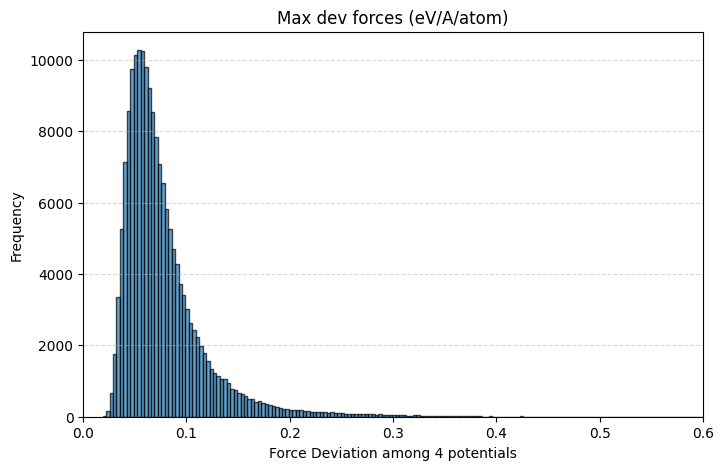

In [5]:
#
# Reading the deviations among the 4 potential (for later active learning):
#

import matplotlib.pyplot as plt

# Read data from the text file:
column_4_values = []
with open("s0/00_iteration/dyn_bias/b120_meta/model_devi.out", "r") as file:
    for line in file:
        if line.strip() and not line.startswith("#"):  # Ignore empty lines and comments.
            parts = line.split()
            if len(parts) >= 4:  # Ensure there are at least 4 columns.
                column_4_values.append(float(parts[4]))  # Column indexing starts at 0.

# Plot histogram:
plt.figure(figsize=(8,5))
plt.hist(column_4_values, bins=200, edgecolor='black', alpha=0.7)
plt.xlim((0, 0.6))
plt.xlabel("Force Deviation among 4 potentials")
plt.ylabel("Frequency")
plt.title("Max dev forces (eV/A/atom)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**1.)**
> First, observe the deviation among the potentials. See cell below. What do you observe?

This histogram pretty much exactly matches the distribution provided by Umberto Raucci on his slide titled "Active Learning (II)".

This distribution is fairly narrow; it starts rising rapidly at around $\sigma = 0.02$ until reaching its maximum at around $\sigma = 0.05$. From there, it starts decaying in an almost exponential fashion. Once we reach $\sigma\geq 0.3$, only very few samples remain, and for $\sigma\geq 0.5$, virtually no samples seem to be recorded.

In terms of interpretation, this suggests that while all of our models clearly never all make identical predictions (as our distribution at $\sigma = 0$ is zero), their predictions are, for the most part, still fairly similar (the majority of samples fall squarely below $\sigma = 0.1$). At the same time, there clearly exist some pathological samples for which our models give wildly different predictions. In the worst of cases, this leads to deviations $\sigma > 0.4$.
<br></br>

In [6]:
!cd s0/00_iteration/dyn_bias/b120_meta_v2 && sed -n '24p' input.lammps

pair_style deepmd ../../1model/frozen_model.pb ../../2model/frozen_model.pb ../../3model/frozen_model.pb ../../newmodel/frozen_model.pb out_freq ${DUMP_FREQ} out_file model_devi.out


In [7]:
!cd s0/00_iteration/dyn_bias/b120_meta_v2 && tail meta.out

   6270200   321.17458     -12440.404      0.74727131    -12439.657      0.0088669777   85.248737      27000          30             30             30             0              0              0            
   6270240   393.06767     -12440.463      0.91454372    -12439.549      0.0088669777  -101.49737      27000          30             30             30             0              0              0            
   6270280   393.77032     -12440.417      0.91617856    -12439.501      0.0088669777   109.90937      27000          30             30             30             0              0              0            
   6270320   403.62089     -12440.557      0.9390977     -12439.618      0.0088669777   107.81157      27000          30             30             30             0              0              0            
   6270360   357.73897     -12440.26       0.83234505    -12439.428      0.0088669777  -85.657497      27000          30             30             30             0        

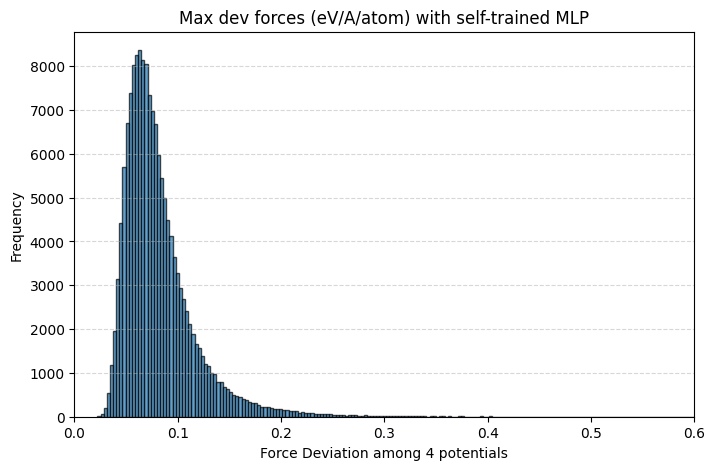

In [8]:
#
# Reading the deviations among the 4 potential (potential 1, 2, 3, and our self-trained one):
#

import matplotlib.pyplot as plt

# Read data from the text file:
column_4_values = []
with open("s0/00_iteration/dyn_bias/b120_meta_v2/model_devi.out", "r") as file:
    for line in file:
        if line.strip() and not line.startswith("#"):  # Ignore empty lines and comments.
            parts = line.split()
            if len(parts) >= 4:  # Ensure there are at least 4 columns.
                column_4_values.append(float(parts[4]))  # Column indexing starts at 0.

# Plot histogram:
plt.figure(figsize=(8,5))
plt.hist(column_4_values, bins=200, edgecolor='black', alpha=0.7)
plt.xlim((0, 0.6))
plt.xlabel("Force Deviation among 4 potentials")
plt.ylabel("Frequency")
plt.title("Max dev forces (eV/A/atom) with self-trained MLP")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**2.)**
> What happens if you repeat the metadynamics adding your "not converged" new_model and keeping also 1, 2, 3 that are perfectly converged?

This looks remarkably similar to the distribution we already observed for our pre-trained MLPs. This suggests that, in spite of of our total training loss not even dropping a full $3$ orders of magnitude during the course of $400,\hspace{-1pt}000$ training steps, our self-trained MLP performs very similarly to the pre-trained ones. I am even inclined to hazard a guess that the pre-trained MLPs were trained the same way as our self-trained one. Notably, in order to get this result, I let the training script run for the maximum number of training steps permitted by it ($400,\hspace{-1pt}000$ steps). If I had, as the task description suggests, run the MLP before it had fully trained, the distribution would presumably look rather different, with significantly more samples at higher $\sigma$ than is the case here.

---

---

# Assigment 3

**1.)** Monitor the COLVAR behavior over time (next cell) as well as the HILLS over time (next cell afterwards). What is the correlation between these two plots?

**2.)** Comment the correlation between the CV value and the trajectory. The colvar is defined in the <code>plumed.dat</code> file. 

**3.)** After a long simulation time, your free energy should be quite converged. The units are kJ/mol. What can you conclude about the proton transfer process?


177614


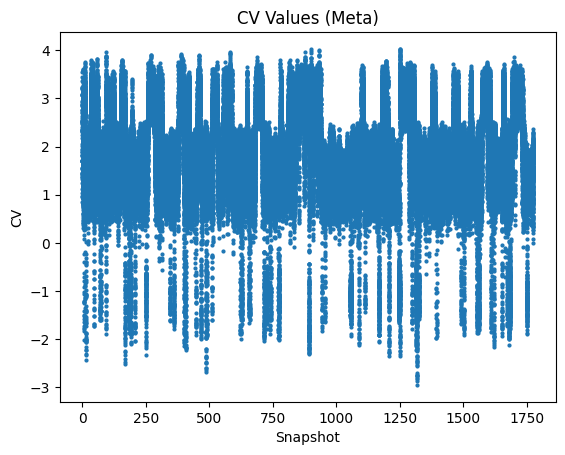

In [9]:
#
# Meta:
#

#
# Plot the dynamics:
#

import matplotlib.pyplot as plt
import numpy as np

# Load data from text file (assuming columns are separated by spaces or tabs):
!cp s0/00_iteration/dyn_bias/b120_meta/COLVAR C2
data = np.loadtxt('C2', usecols=(0,3))
data = data [:-1]

print(len(data))

# Extract first and second columns:
x = data[:, 0]  # First column.
y = data[:, 1]  # Second column.

# Plot:
plt.plot(x, y, marker='o', linestyle='', markersize=2)
plt.xlabel('Snapshot')
plt.ylabel('CV')
plt.title('CV Values (Meta)')
plt.show()

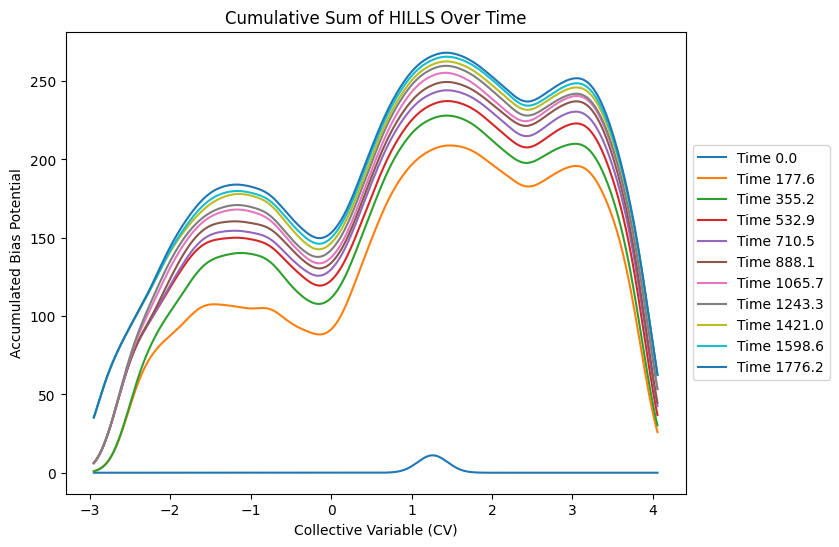

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load HILLS file (ignoring comment lines):
df = pd.read_csv('s0/00_iteration/dyn_bias/b120_meta/HILLS', sep='\s+', comment='#', header=None)
df.columns = ["time", "cv", "sigma_cv", "height", "biasf"]

# Define a grid over the CV space:
cv_min, cv_max = df["cv"].min(), df["cv"].max()
cv_grid = np.linspace(cv_min, cv_max, 1000)  # High resolution grid

# Initialize cumulative bias array:
cumulative_bias = np.zeros((len(df), len(cv_grid)))

# Compute cumulative bias over time:
for i in range(len(df)):
    h, c, sigma = df.loc[i, ["height", "cv", "sigma_cv"]]
    cumulative_bias[i] = cumulative_bias[i - 1] + h * np.exp(-((cv_grid - c)**2) / (2 * sigma**2))

# Plot successive cumulative bias landscapes:
plt.figure(figsize=(8, 6))
for i in range(0, len(df), max(1, len(df) // 10)):  # Plot 10 evenly spaced curves
    plt.plot(cv_grid, cumulative_bias[i], label=f'Time {df.loc[i, "time"]:.1f}')

plt.xlabel("Collective Variable (CV)")
plt.ylabel("Accumulated Bias Potential")
plt.title("Cumulative Sum of HILLS Over Time")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

**1.)**
> Monitor the COLVAR behavior over time (next cell) as well as the HILLS over time (next cell afterwards). What is the correlation between these two plots?

The more a given collective variable ($\text{CV}$) value (and its immediate vicinity) has been sampled, the higher its corresponding value of the bias potential will be. This is because metadynamics sampling works by adding Gaussian contributions to the bias potential in positions at which it has sampled. Through this, the scheme clearly incentivises itself to sample elsewhere in future steps. This correlation between sampling at some $\text{CV}$ value and the growth of the bias potential at and around this value should also become visible when inspecting the time evolution of the bias potential and cross-referencing this time evolution with the $\text{CV}$ sampling plot. However, due to the total length of the simulation performed here ($>7,\hspace{-1pt}100,\hspace{-1pt}000$ steps), this is a bit difficult to do for the HILLS plot given above.
<br></br>

In [11]:
#
# Reading the trajectory:
# 

mytraj = read("s0/00_iteration/dyn_bias/b120_meta/dump.xyz",":")
view_trajectory(mytraj)

NGLWidget(max_frame=177634)

**2.)**
> Comment the correlation between the CV value and the trajectory. The colvar is defined in the <code>plumed.dat</code> file.

Recalling that the collective variable ($\text{CV}$) is defined as: $\text{CV} = d_2 - d_1$, where $d_1$ and $d_2$ are the distances between the proton and the primary & secondary nitrogen atoms, respectively (the "primary" nitrogen atom here is the one to which the proton is bonded initially). Obviously, if $\text{CV} > 0$, the proton is closer to the primary nitrogen atom than the secondary one. This is also where the initial (lowest free energy) configuration is located ($\text{CV} \approx 1.37\,\text{Å}$). Higher $\text{CV}$ values at reasonable energies can be achieved by relative rotations around the $\text{CC}$ bond connecting the two aromatic rings. In particular, the local free energy minimum at $\text{CV}\approx 3.08\,\text{Å}$ corresponds to a configuration in which the two rings have been rotated $180^{\circ}$ relative to each other with the proton still bonded to the primary nitrogen atom. Lower $\text{CV}$ values can obviously be achieved by moving the proton towards the secondary nitrogen atom. In particular, the local free energy minimum at $\text{CV}\approx -1.14\,\text{Å}$ is probably where the proton has decoupled from the primary nitrogen atom and bonded with the secondary one.
<br></br>

In [12]:
print('CV value for initial configuration:')
print(f'{mytraj[0].get_distance(11, 5) - mytraj[0].get_distance(4, 5)} Å')

CV value for initial configuration:
1.3729635933112168 Å


In [13]:
print('CV value for configuration, where the rings have been rotated 180° relative to each other:')
print(f'{mytraj[53].get_distance(11, 5) - mytraj[53].get_distance(4, 5)} Å')

CV value for configuration, where the rings have been rotated 180° relative to each other:
3.0783045509827636 Å


In [14]:
print('CV value for configuration, where the proton has moved from the initial nitrogen atom to the other one:')
print(f'{mytraj[1246].get_distance(11, 5) - mytraj[1246].get_distance(4, 5)} Å')

CV value for configuration, where the proton has moved from the initial nitrogen atom to the other one:
-1.1378858640239171 Å


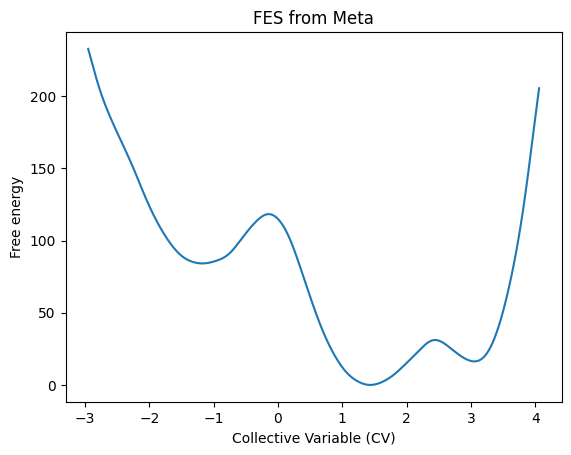

In [15]:
fes_meta = -cumulative_bias[-1] - np.min(-cumulative_bias[-1])
plt.plot(cv_grid, fes_meta)
plt.xlabel('Collective Variable (CV)')
plt.ylabel('Free energy')
plt.title('FES from Meta')
plt.show()

In [16]:
feb_meta = np.max(fes_meta[300:500])
print('Free energy barrier (ΔF‡) of the proton transfer reaction (META):')
print(f'{feb_meta} kJ/mol')
print(f'{0.0103641 * feb_meta} eV')

Free energy barrier (ΔF‡) of the proton transfer reaction (META):
118.37306476634936 kJ/mol
1.2268302805449214 eV


In [17]:
feb_meta_rot = np.max(fes_meta[600:850])
print('Free energy barrier (ΔF‡) of the 180° rotation of the two rings relative to each other (META):')
print(f'{feb_meta_rot} kJ/mol')
print(f'{0.0103641 * feb_meta_rot} eV')

Free energy barrier (ΔF‡) of the 180° rotation of the two rings relative to each other (META):
31.14231950653442 kJ/mol
0.3227621135976734 eV


In [18]:
k_meta = (1.380649e-23 * 300) / 6.62607015e-34 * np.exp(-(1e3 * feb_meta) / (8.3145 * 300))
print('Rate constant (k) of the proton transfer reaction (META):')
print(f'{k_meta} s⁻¹')

Rate constant (k) of the proton transfer reaction (META):
1.534130058607602e-08 s⁻¹


In [19]:
k_meta_rot = (1.380649e-23 * 300) / 6.62607015e-34 * np.exp(-(1e3 * feb_meta_rot) / (8.3145 * 300))
print('Rate constant (k) of the 180° rotation of the two rings relative to each other (META):')
print(f'{k_meta_rot} s⁻¹')

Rate constant (k) of the 180° rotation of the two rings relative to each other (META):
23643908.15893059 s⁻¹


In [20]:
rfe_meta = np.min(fes_meta[150:400])
print('Reaction free energy (ΔᵣF) of the proton transfer reaction (META):')
print(f'{rfe_meta} kJ/mol')
print(f'{0.0103641 * rfe_meta} eV')

Reaction free energy (ΔᵣF) of the proton transfer reaction (META):
84.18899404549387 kJ/mol
0.872543153186903 eV


In [21]:
rfe_meta_rot = np.min(fes_meta[800:1000])
print('Reaction free energy (ΔᵣF) of the 180° rotation of the two rings relative to each other (META):')
print(f'{rfe_meta_rot} kJ/mol')
print(f'{0.0103641 * rfe_meta_rot} eV')

Reaction free energy (ΔᵣF) of the 180° rotation of the two rings relative to each other (META):
16.285744219020415 kJ/mol
0.16878708166034948 eV


**3.)**
> After a long simulation time, your free energy should be quite converged. The units are kJ/mol. What can you conclude about the proton transfer process?

A free energy surface plot is given above. It can be generated by taking the negative of the latest bias potential. Obviously, this yields a somewhat arbitrary offset of the curve along the $y$-axis. Considering that, however, only free energy differences are really interesting to us, this should be fine.

A notable piece of information we can gather is that the free energy barrier $\Delta F^\ddagger$ of the proton transfer reaction (proton moves from the primary to the secondary nitrogen atom) is approximately $118.4\,\text{kJ}/\text{mol}\approx 1.227\,\text{eV}$. This allows us to estimate the rate of the reaction by computing its rate constant using an Eyring-like equation: $k = \frac{k_BT}{h}\cdot e^{-\Delta F^\ddagger / (RT)}\approx 1.534\cdot 10^{-8}\,\text{s}^{-1}$ (this is a tiny value; but we are also dealing with a very high free energy reaction barrier).

Another arguably even more well-known quantity that is derivable from the free energy surface is the reaction free energy $\Delta_r F$. For our proton transfer reaction, this is $84.19\,\text{kJ}/\text{mol}\approx 0.873\,\text{eV} > 0$, meaning that this reaction is endergonic. We can therefore conclude that it should not happen spontaneously.

Further properties of interest are derivable from the free energy surface. For instance, the interior of our reaction path contains one local maximum and no local minima, which lets us conclude that our reaction has a single transition state with no reaction intermediates.

---

---

# Assignment 4: Do the same with OPES

Move to the directory <code>s0/00_iteration/dyn_bias/b120_opes</code> and execute

<code> bash run_opes.sh > opes.out & </code>

**1.)** Monitor COLVAR, the trajectory, the histogram of the COLVAR, the bias in time, and the FES obtained with a script. Comment on all this and compare with the META example as well as the considerations in the [PLUMED WEBSITE](https://www.plumed.org/doc-v2.9/user-doc/html/opes-metad.html).

**2.)** Do you observe many transitions? What happens in the system? What does the FES tell us?

In [22]:
!cd s0/00_iteration/dyn_bias/b120_opes && tail opes.out

   7102640   244.7103      -12442.942      0.56936319    -12442.373      0.0088669777   1.5888708      27000          30             30             30             0              0              0            
   7102680   260.99618     -12442.892      0.60725528    -12442.285      0.0088669777  -106.86768      27000          30             30             30             0              0              0            
   7102720   299.93467     -12442.927      0.69785278    -12442.229      0.0088669777  -124.53686      27000          30             30             30             0              0              0            
   7102760   276.94448     -12442.795      0.6443619     -12442.15       0.0088669777  -78.23862       27000          30             30             30             0              0              0            
   7102800   322.96527     -12442.941      0.75143768    -12442.19       0.0088669777  -139.08138      27000          30             30             30             0        

177546


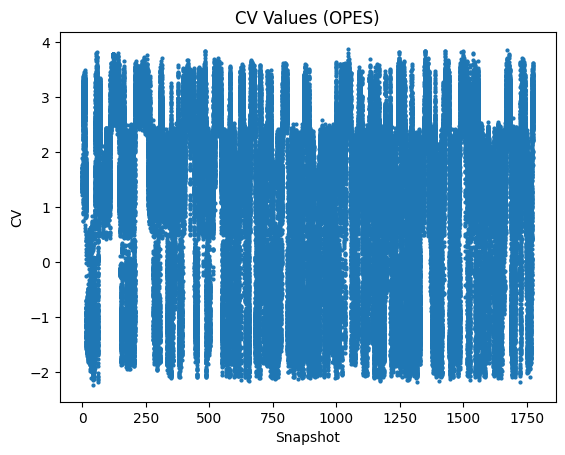

In [23]:
#
# Plot the dynamics:
#

import matplotlib.pyplot as plt
import numpy as np

# Load data from text file (assuming columns are separated by spaces or tabs):
!cp s0/00_iteration/dyn_bias/b120_opes/COLVAR C2
data = np.loadtxt('C2',usecols=(0,3))

print(len(data))

# Extract first and second columns:
x = data[:, 0]  # First column.
y = data[:, 1]  # Second column.

# Plot:
plt.plot(x, y, marker='o', linestyle='', markersize=2)
plt.xlabel('Snapshot')
plt.ylabel('CV')
plt.title('CV Values (OPES)')
plt.show()

In [24]:
#
# Reading the trajectory:
# 

mytraj = read("s0/00_iteration/dyn_bias/b120_opes/dump.xyz",":")
view_trajectory(mytraj)

NGLWidget(max_frame=177575)

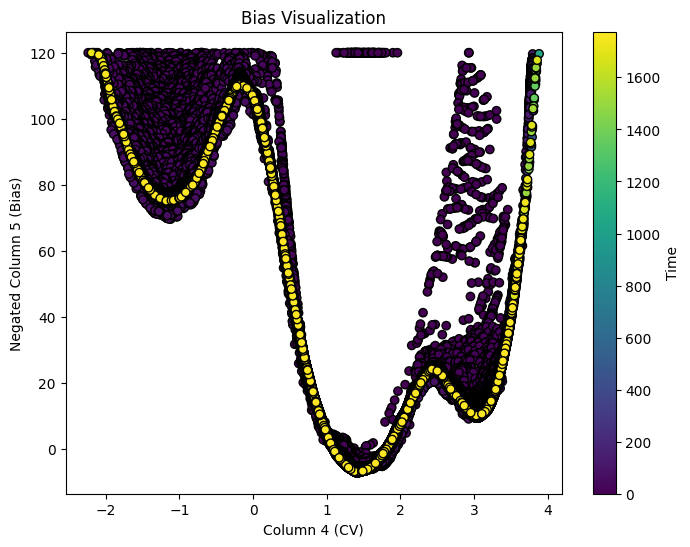

In [25]:
#
# Plotting the BIAS in time:
#

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load COLVAR file (ignoring comment lines):
df = pd.read_csv("s0/00_iteration/dyn_bias/b120_opes/COLVAR", sep='\s+', comment='#', header=None)

# Extract relevant columns:
x_values = df.iloc[:, 3]   # Fourth column.
y_values = -df.iloc[:, 4]  # Fifth column (changing sign).
time_values = df.iloc[:, 0]  # First column for coloring.

# Create scatter plot with color coding by time:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(x_values, y_values, c=time_values, cmap='viridis', edgecolor='k')
plt.colorbar(scatter, label="Time")
plt.xlabel("Column 4 (CV)")
plt.ylabel("Negated Column 5 (Bias)")
plt.title("Bias Visualization")
plt.show()

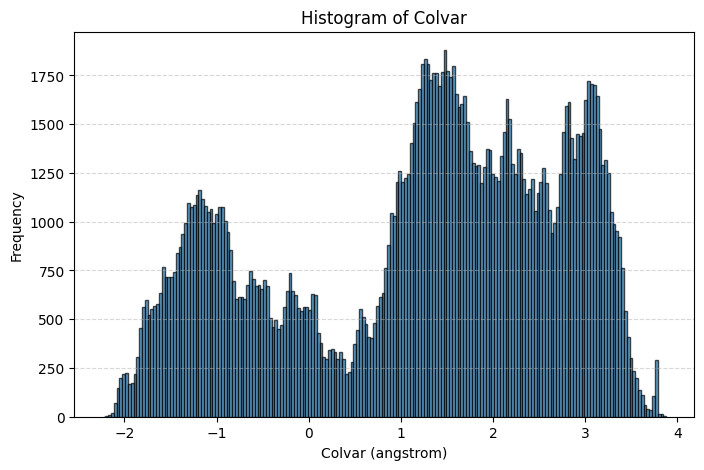

In [26]:
#
# Histogram of the colvar.
# Reading the deviations.
#

import matplotlib.pyplot as plt

# Read data from the text file:
column_4_values = []
with open("s0/00_iteration/dyn_bias/b120_opes/COLVAR", "r") as file:
    for line in file:
        if line.strip() and not line.startswith("#"):  # Ignore empty lines and comments.
            parts = line.split()
            if len(parts) >= 4:  # Ensure there are at least 4 columns.
                column_4_values.append(float(parts[3]))  # Column indexing starts at 0.

# Plot histogram:
plt.figure(figsize=(8,5))
plt.hist(column_4_values, bins=200, edgecolor='black', alpha=0.7)
plt.xlabel("Colvar (angstrom)")
plt.ylabel("Frequency")
plt.title("Histogram of Colvar")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

/home/jovyan/MMM_2025/Exercise_12

 using cv "cv" found at column 4
 using bias "opes.bias" found at column 5
                              
101


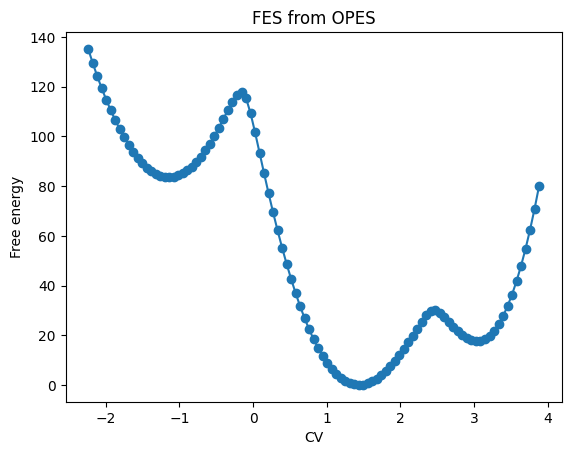

In [27]:
#
# Extract FES from the BIAS by applying appropriate weigths.
# Plot the dynamics.
#

import matplotlib.pyplot as plt
import numpy as np

# Load data from text file (assuming columns are separated by spaces or tabs):
!cat s0/00_iteration/dyn_bias/b120_opes/COLVAR  | head -n -1 > C2 
!pwd
!cp s0/00_iteration/dyn_bias/b120_opes/FES_from_Reweighting.py .
!python ./FES_from_Reweighting.py --sigma 0.08 --temp 300 --colvar C2  --cv 4 
data = np.loadtxt('fes-rew.dat')

print(len(data))

# Extract first and second columns:
x = data[:, 0]  # First column.
y = data[:, 1]  # Second column.

# Plot:
plt.plot(x, y, marker='o', linestyle='-')
plt.xlabel('CV')
plt.ylabel('Free energy')
plt.title('FES from OPES')
plt.show()

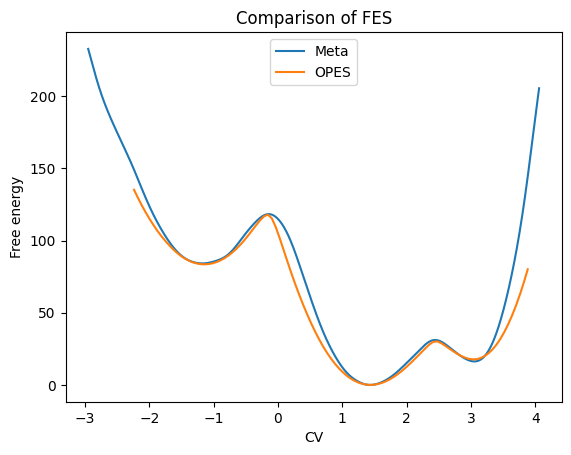

In [28]:
fes_opes = y - np.min(y)
plt.plot(cv_grid, fes_meta, label='Meta')
plt.plot(x, fes_opes, linestyle='-', label='OPES')
plt.xlabel('CV')
plt.ylabel('Free energy')
plt.title('Comparison of FES')
plt.legend(loc='upper center')
plt.show()

In [29]:
feb_opes = np.max(fes_opes[20:50])
print('Free energy barrier (ΔF‡) of the proton transfer reaction (OPES):')
print(f'{feb_opes} kJ/mol')
print(f'{0.0103641 * feb_opes} eV')

Free energy barrier (ΔF‡) of the proton transfer reaction (OPES):
118.010755 kJ/mol
1.2230752658955 eV


In [30]:
feb_opes_rot = np.max(fes_opes[60:90])
print('Free energy barrier (ΔF‡) of the 180° rotation of the two rings relative to each other (OPES):')
print(f'{feb_opes_rot} kJ/mol')
print(f'{0.0103641 * feb_opes_rot} eV')

Free energy barrier (ΔF‡) of the 180° rotation of the two rings relative to each other (OPES):
30.17595 kJ/mol
0.312746563395 eV


In [31]:
k_opes = (1.380649e-23 * 300) / 6.62607015e-34 * np.exp(-(1e3 * feb_opes) / (8.3145 * 300))
print('Rate constant (k) of the proton transfer reaction (OPES):')
print(f'{k_opes} s⁻¹')

Rate constant (k) of the proton transfer reaction (OPES):
1.773962348829665e-08 s⁻¹


In [32]:
k_opes_rot = (1.380649e-23 * 300) / 6.62607015e-34 * np.exp(-(1e3 * feb_opes_rot) / (8.3145 * 300))
print('Rate constant (k) of the 180° rotation of the two rings relative to each other (OPES):')
print(f'{k_opes_rot} s⁻¹')

Rate constant (k) of the 180° rotation of the two rings relative to each other (OPES):
34831734.35772378 s⁻¹


In [33]:
rfe_opes = np.min(fes_opes[:30])
print('Reaction free energy (ΔᵣF) of the proton transfer reaction (OPES):')
print(f'{rfe_opes} kJ/mol')
print(f'{0.0103641 * rfe_opes} eV')

Reaction free energy (ΔᵣF) of the proton transfer reaction (OPES):
83.587682 kJ/mol
0.8663110950162 eV


In [34]:
rfe_opes_rot = np.min(fes_opes[80:])
print('Reaction free energy (ΔᵣF) of the 180° rotation of the two rings relative to each other (OPES):')
print(f'{rfe_opes_rot} kJ/mol')
print(f'{0.0103641 * rfe_opes_rot} eV')

Reaction free energy (ΔᵣF) of the 180° rotation of the two rings relative to each other (OPES):
17.698267 kJ/mol
0.1834266090147 eV


In [35]:
print('Proton transfer reaction, ΔF‡(META) - ΔF‡(OPES):')
print(f'{feb_meta - feb_opes} kJ/mol ({100 * abs((feb_opes - feb_meta) / feb_meta)}% relative deviation)')

Proton transfer reaction, ΔF‡(META) - ΔF‡(OPES):
0.3623097663493553 kJ/mol (0.3060745001952094% relative deviation)


In [36]:
print('180° relative ring rotation, ΔF‡(META) - ΔF‡(OPES):')
print(f'{feb_meta_rot - feb_opes_rot} kJ/mol ({100 * abs((feb_opes_rot - feb_meta_rot) / feb_meta_rot)}% relative deviation)')

180° relative ring rotation, ΔF‡(META) - ΔF‡(OPES):
0.96636950653442 kJ/mol (3.103074921351481% relative deviation)


In [37]:
print('Proton transfer reaction, ΔᵣF(META) - ΔᵣF(OPES):')
print(f'{rfe_meta - rfe_opes} kJ/mol ({100 * abs((rfe_opes - rfe_meta) / rfe_meta)}% relative deviation)')

Proton transfer reaction, ΔᵣF(META) - ΔᵣF(OPES):
0.6013120454938701 kJ/mol (0.7142406823021716% relative deviation)


In [38]:
print('180° relative ring rotation, ΔᵣF(META) - ΔᵣF(OPES):')
print(f'{rfe_meta_rot - rfe_opes_rot} kJ/mol ({100 * abs((rfe_opes_rot - rfe_meta_rot) / rfe_meta_rot)}% relative deviation)')

180° relative ring rotation, ΔᵣF(META) - ΔᵣF(OPES):
-1.412522780979586 kJ/mol (8.673369555502873% relative deviation)


**1.)**
> Monitor COLVAR, the trajectory, the histogram of the COLVAR, the bias in time, and the FES obtained with a script. Comment on all this and compare with the META example as well as the considerations in the [PLUMED WEBSITE](https://www.plumed.org/doc-v2.9/user-doc/html/opes-metad.html).

An apparent difference between the META and the OPES sampling is that the latter seems to sample a lot more uniformly between the states with $\text{CV}>0$ and $\text{CV}<0$.

These differences in sampling strategy also become apparent when considering the META- and OPES-generated trajectories. As it turns out, the META trajectory explores the proton transfer reaction for the first time significantly earlier (after around $500$ steps). In contrast, the OPES trajectory only does so after $1,\hspace{-1pt}500$ steps. However, the META sampling only samples the proton transfer once at around $500$ steps and after that immediately returns to sampling relative ring rotations around the $\text{CC}$ $\sigma$-bond connecting the two rings. In contrast, the OPES trajectory spends the entirety of steps $1,\hspace{-1pt}500$ to $5,\hspace{-1pt}000$ only sampling the proton transfer reaction, performing this reaction several times during this interval. This trend also manifests itself in the $\text{CV}$ value plots, where in the case of META, generally only short spikes below $\text{CV} = 0$ are visible. In contrast, in the OPES plot, the sections sampling $\text{CV} < 0$ tend to be significantly longer/thicker in the plot.

The OPES bias evolution in time seems to generally agree with the $\text{CV}$ value plot (in the sense that if a given $\text{CV}$ value is sampled according to the $\text{CV}$ plot, an updated node in the same position is added to the bias potential). Notably, our bias potential plot plots the **negative** bias potential (hence also why its shape after $\approx 7,\hspace{-1pt}100,\hspace{-1pt}000$ strongly resembles that of the output free energy surface). What distinguishes it from the META bias potential is that while the META bias potential can only grow (as it can only add Gaussians, not subtract them), OPES can effectively remove existing contributions to its bias potential (hence why we can clearly see that the final bias potential is not maximal everywhere relative to previous bias potentials).

Our final output free energy surface is extremely similar to the one we found through META sampling. This is to be expected (but also reassuring) considering that we sampled using both of them for approximately $7,\hspace{-1pt}100,\hspace{-1pt}000$ steps. What is especially convenient is that we may now compare the free energy barriers $\Delta F^\ddagger$ that both schemes yield. The META- and OPES-calculated free energy barriers for the proton transfer reaction are $118.4\,\text{kJ}/\text{mol}\approx 1.227\,\text{eV}$ and $118.0\,\text{kJ}/\text{mol}\approx 1.223\,\text{eV}$, respectively. This puts the relative deviation of the latter from the former at only approximately $0.31\%$, which is a very impressive degree of consistency. With respect to the $180^{\circ}$ relative rotation of the two rings, the META- and OPES-calculated free energy barriers are $31.14\,\text{kJ}/\text{mol}\approx 0.323\,\text{eV}$ and $30.18\,\text{kJ}/\text{mol}\approx 0.310\,\text{eV}$, respectively. This equates to a relative deviation of the latter from the former of approximately $3.1\%$, which, while not as good as the agreement for the proton transfer reaction, still seems pretty decent.

Another quantity we can, of course, compare between the two free energy surfaces is the reaction free energy $\Delta_r F$. For the proton transfer reaction, this is approximately $84.19\,\text{kJ}/\text{mol}\approx 0.873\,\text{eV}$ and $83.59\,\text{kJ}/\text{mol} \approx 0.866\,\text{eV}$ as reported by META and OPES, respectively. This corresponds to a moderate deviation of approximately $0.71\%$ of the latter from the former. For the $180^{\circ}$ rotation of the two rings relative to each other META and OPES yield reaction free energies of $16.29\,\text{kJ}/\text{mol}\approx 0.169\,\text{eV}$ and $17.70\,\text{kJ}/\text{mol}\approx 0.183\,\text{eV}$, respectively. This corresponds to a significantly larger absolute deviation of the latter from the former of approximately $8.67\%$ (although the conclusion that the process is endergonic still very much remains the same).

An interesting consideration made by the PLUMED documentation is that for the example they consider, they note that "with metadynamics, more transitions are present, especially in the initial part of the simulation." I do not think this necessarily agrees with what is visible in our simulations. It is a bit difficult to argue about the amount of transitions "in the initial part of the simulation" considering that by looking at the OPES trajectory it is not always entirely clear what should count as a "transition" and would should not (in particular, should the situation in which OPES samples the transition state but then returns to to whatever side of the transition state it previously sampled count as a transition, as no transition, or maybe as half a transition?). What is, however, clear is that over its entire trajectory, OPES has significantly more transitions than META has (which we already somewhat discussed earlier based on the evolution of the $\text{CV}$ values).

Another remarkable point is that we see similar, strange-looking initial bias potential points in the bias potential visualisation provided in the PLUMED documentation as we do in our OPES bias potential plot (meaning that Prof. Passerone need not fear that these points are leftovers from some test he did prior to finalising this exercise).
<br></br>

**2.)**
> Do you observe many transitions?

As already outlined above, we do indeed see many transitions in our OPES-sampled trajectory (which in absolute terms is unsurprising considering the total length of our simulation).

> What happens in the system?

As already noted in my discussion of the different $\text{CV}$ configurations, a full transition from $1.37\text{Å}$ to $-1.14\text{Å}$ effecticely boils down to the proton initially attached to the primary nitrogen atom, decoupling from this nitrogen atom and bonding with the secondary nitrogen atom (embedded in the other ring), i.e., we have an intra-molecular proton transfer reaction. The reverse transition reverses this process.

> What does the FES tell us?

As already discussed earlier, the free energy surface allows us to compute free energy barriers ($\Delta F^\ddagger$) for a given reaction by subtracting the free energy of the reactants from the maximum free energy along the reaction coordinate. This allows us to estimate the rate of the reaction by computing the rate constant using an Eyring-like equation $k = \frac{k_BT}{h}\cdot e^{-\Delta F^\ddagger / (RT)}\approx 1.774\cdot 10^{-8}\,\text{s}^{-1}$. Also, by computing the reaction free energy $\Delta_r F$ by subtracting the reactant's free energy from the product's free energy, we can predict whether the reaction happens spontaneously or not. As, in the case of our proton transfer reaction clearly $\Delta_r F < 0$, we can conclude that our reaction will not happen spontaneously (although, by the same considerations, the inverse reaction would).

---